# 🌗 Dynamic Range Alignment

This notebook (will) implement dynamic range alignment for each pair of digital and film images.
Goal: To line up the grey-levels/luminance of each pair of images so that the model does not to adjust luminance levels

A good starting point is [this OpenCV page](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html)


In [23]:
import autorootcwd

In [24]:
import numpy as np
import cv2 as cv

from matplotlib import pyplot as plt

In [25]:
from typing import List, Tuple, Union

In [51]:
def align_luminance(im1_path, im2_path):
    """
    Align the luminance of two images
    """
    # Convert to LAB
    lab1 = cv.cvtColor(cv.imread(im1_path), cv.COLOR_BGR2LAB)
    lab2 = cv.cvtColor(cv.imread(im2_path), cv.COLOR_BGR2LAB)

    # Split into channels
    l1, a1, b1 = cv.split(lab1)
    l2, a2, b2 = cv.split(lab2)

    # Align luminance histogram of the two images
    l1_hist, _ = np.histogram(l1.flatten(), 256, [0, 256])

    # Align the mean luminance of the two images
    l2 = cv.add(l2, np.mean(l1) - np.mean(l2))

    # Merge the channels back together
    lab2 = cv.merge((l2, a2, b2))

    # Convert back to BGR
    return cv.cvtColor(lab1, cv.COLOR_LAB2RGB), cv.cvtColor(lab2, cv.COLOR_LAB2RGB)


In [52]:
def equalize_histogram(img_path):

    img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
    assert img is not None, "file could not be read, check with os.path.exists()"
    
    hist,bins = np.histogram(img.flatten(),256,[0,256])
    
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf.max()
    
    plt.plot(cdf_normalized, color = 'b')
    plt.hist(img.flatten(),256,[0,256], color = 'r')
    plt.xlim([0,256])
    plt.legend(('cdf','histogram'), loc = 'upper left')
    plt.show()

    # find the minimum histogram value (excluding 0) and apply the histogram equalization equation
    cdf_m = np.ma.masked_equal(cdf,0)
    cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
    cdf = np.ma.filled(cdf_m,0).astype('uint8')

    img_normalized = cdf[img]

    # its histogram and cdf as before 
    hist,bins = np.histogram(img_normalized.flatten(),256,[0,256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    plt.plot(cdf_normalized, color = 'b')
    plt.hist(img_normalized.flatten(),256,[0,256], color = 'r')
    plt.xlim([0,256])
    plt.legend(('cdf','histogram'), loc = 'upper left')
    plt.show()

    fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
    axs[0].imshow(img)
    axs[1].imshow(img_normalized)

    return img_normalized

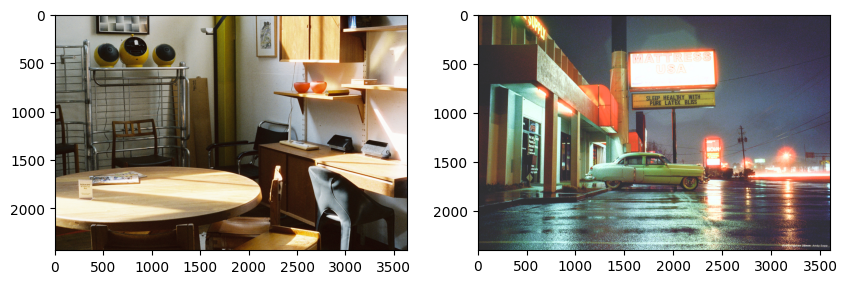

In [53]:
# Load image example
im1_path = 'imgs/table_cafe_film.JPG'
im2_path = 'imgs/cinestill-800t.jpg'

# call function on example images
aligned1, aligned2 = align_luminance(im1_path, im2_path)

# Display the two images

fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
axs[0].imshow(aligned1)
axs[1].imshow(aligned2)


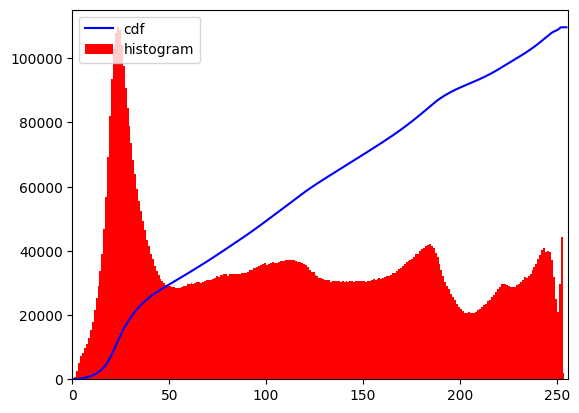

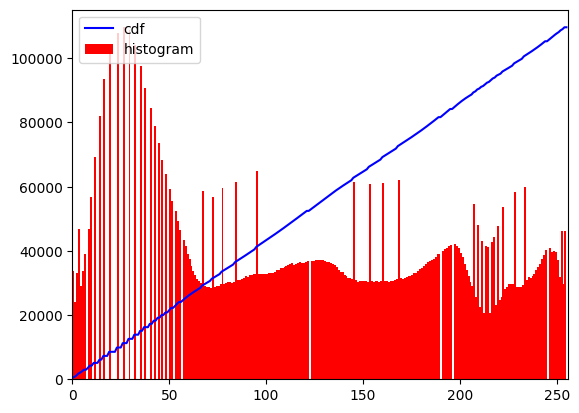

array([[208, 210, 206, ..., 201, 193, 193],
       [209, 210, 207, ..., 200, 195, 195],
       [201, 206, 207, ..., 204, 209, 208],
       ...,
       [ 42,  37,  32, ...,  51,  44,  53],
       [ 50,  44,  35, ...,  48,  44,  44],
       [ 53,  60,  61, ...,  50,  55,  55]], dtype=uint8)

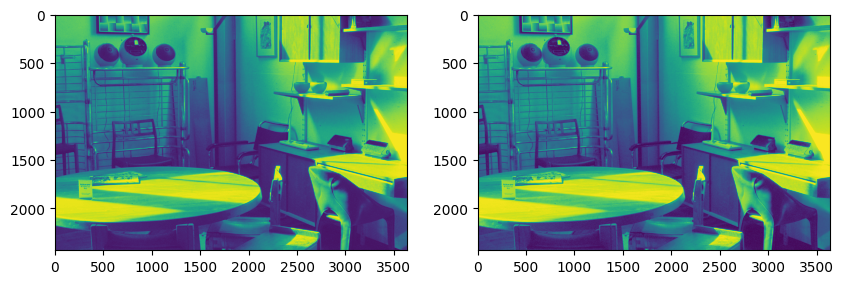

In [54]:
equalize_histogram('imgs/table_cafe_film.JPG')